# Aufgabe 5
## Bestimmung der Werte für Verdampfungswärme mit Fit
FÜr Aufgabe 5 sollen für aus den Messwerten die Verdampfungswärme, mittels der Clausius-Clapeyron-Gleichung, ermitteln. DIese lautet wie folgt:
$$\frac{d p_s}{dT} = \frac{Q_{23}}{T \cdot \Delta V_m}$$
Dabei ist $V_m$ der Unterschied des Volumens an der Maxwell-Geraden. Als erstes müssen wir also $p_s$ und $T$ als plot darstellen um daraus $\frac{dp_s}{dT}$ zu bekommen. Mithile der Formel und der Umstellung von $V_m = \frac{1}{n}(V_G-V_F)$ können wir dann die Verdampfungswärme berechnen.
$$Q_{23}(T) = \frac{(V_G - V_F)}{n}T\frac{dp_s}{dT}$$

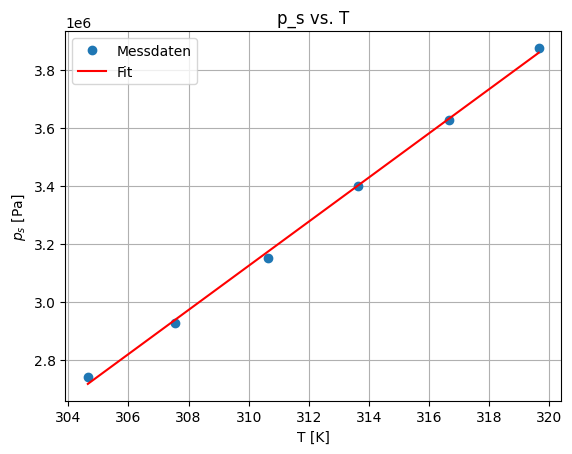

Q für T=304.65 K: 10179.64 J/mol
Q für T=307.55 K: 8408.08 J/mol
Q für T=310.65 K: 6605.53 J/mol
Q für T=313.65 K: 4763.80 J/mol
Q für T=316.65 K: 2885.62 J/mol
Q für T=319.65 K: 970.99 J/mol


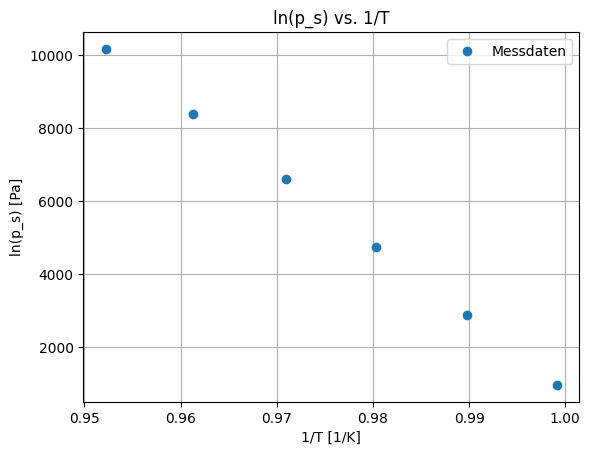

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

#Konstante
n = 0.001253 # in mol
a = 0.79 
b = 0.88*1e-4
R = 8.314 # J/(mol*K)
Q_23 = []
T_k = ((8 * a)/(27*R*b))

# Gegebene Messwerte
T = np.array([304.65, 307.55, 310.65, 313.65, 316.65, 319.65])  # in K
p_s = np.array([2742000, 2925000, 3150000, 3400000, 3625000, 3875000])  # in Pa
v_g = np.array([0.9, 0.8, 0.7, 0.6, 0.5, 0.4])  # in m^3/mol
v_f = np.array([0.35, 0.35, 0.35, 0.35, 0.35, 0.35])  # in m^3/mol
v_g = v_g * 1e-6
v_f = v_f * 1e-6
fit_p_s = np.polyfit(T, p_s, 1)



#  Steigung der Geraden
slope = fit_p_s[0]
# y-Achsenabschnitt der Geraden
intercept = fit_p_s[1]

# Plot
plt.plot(T, p_s, 'o', label='Messdaten')
plt.plot(T, np.polyval(fit_p_s, T), 'r-', label='Fit')
plt.xlabel('T [K]')
plt.ylabel(r'$p_s$ [Pa]')
plt.legend()
plt.title('p_s vs. T')
plt.grid(True)
plt.show()

# Verdampufngswärme berechnen
for i in range(len(T)):
    Q = ((v_g[i] - v_f[i]) * T[i] * slope)/n
    Q_23.append(Q)
    print(f"Q für T={T[i]} K: {Q:.2f} J/mol")

# Plott der Verdampfungswärme zu T/Tk
plt.plot(T/T_k, Q_23, 'o', label='Messdaten')
plt.xlabel('1/T [1/K]')
plt.ylabel('ln(p_s) [Pa]')
plt.legend()
plt.title('ln(p_s) vs. 1/T')
plt.grid(True)
plt.show()



Für den Fall das $T\approx T_K$, 